In [1]:
import sys
sys.path.append('/exp/icarus/app/users/zihaolin/REWEIGHTworkdir/')
from BDTReweight.json_reweighter import reaction_frame_2p2h_momenta, load_json_reweighter # the json module is designed to be standalone.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Read from saved json BDT reweighter object and reweight
BDT reweighter training work flow:
1. Prepare reweight variables from source and target sample;
2. Train BDT reweighter using these variables and save to json object.

Future use work flow:
1. Prepare reweight variables from your source sample;
2. Read json reweighter and predict weights using reweight variables.


For the pp final state **SuSAv2 inclusive 2p2h** -> **Valencia exclusive 2p2h** reweight, reweight variables are:

* leading proton $p_x$, $p_y$, $p_z$
* subleading proton $p_x$, $p_y$, $p_z$
* muon $p_y$, $p_z$

in **reaction frame coordinates**, where neutrino direction is in $+\hat{z}$, and muon transverse momentum is in $-\hat{y}$. See FIG. 2 of <https://doi.org/10.1103/7zty-f2qj>.

Optional: include $E_\nu$ in training.


Note:
* The BDT reweight is a shape only reweight. We need to control the magnitude ourselves. Need discussions here.
* The json interface is designed to be standalone. Function load_json_reweighter() only requires numpy and a few other raw python supports.
* The cpp json interface will also be implemented.

## Test BDT reweight pp out-going state events

In [2]:
# drawing variables
drawing_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E', 'q0', 'q3', 'Q2'   
]
# read muon, proton kinematics from pre-processed csv files, already in reaction plane frame
df_source = pd.read_csv('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/AR23SuSAv2_ICARUS_NuMI_2p2h_pp_states.csv')
df_target = pd.read_csv('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/newValencia_ICARUS_NuMI_2p2h_pp_states.csv')
print("source csv columns:", df_source.columns)
print("target csv columns:", df_target.columns)


source csv columns: Index(['init_neutrino_E', 'q0', 'q3', 'Q2', 'leading_muon_px',
       'leading_muon_py', 'leading_muon_pz', 'leading_proton_px',
       'leading_proton_py', 'leading_proton_pz', 'subleading_proton_px',
       'subleading_proton_py', 'subleading_proton_pz', 'weight'],
      dtype='object')
target csv columns: Index(['leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
       'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
       'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
       'weight', 'init_neutrino_E', 'q0', 'q3', 'Q2'],
      dtype='object')


### pp reweight training without $E_\nu$:

In [3]:
# reweight variables (the ORDER matters) 
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz', 
    # 'init_neutrino_E'
]

# read reweighter from json
reweighter = load_json_reweighter('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_NuMI_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pp_bdtreweighter.json')
# input_features = np.array([
#     df_source['leading_proton_px'], df_source['leading_proton_py'], df_source['leading_proton_pz'],
#     df_source['subleading_proton_px'], df_source['subleading_proton_py'], df_source['subleading_proton_pz'],
#     df_source['leading_muon_py'], df_source['leading_muon_pz']
#     ]).T
input_features = np.array(df_source[reweight_variables])

In [4]:
# use reweighter to predict weights for source sample
new_weights = reweighter.predict_weights(input_features)
print(new_weights)


[0.22005556 0.15238865 0.10632251 ... 0.12266762 0.14388484 0.52014723]


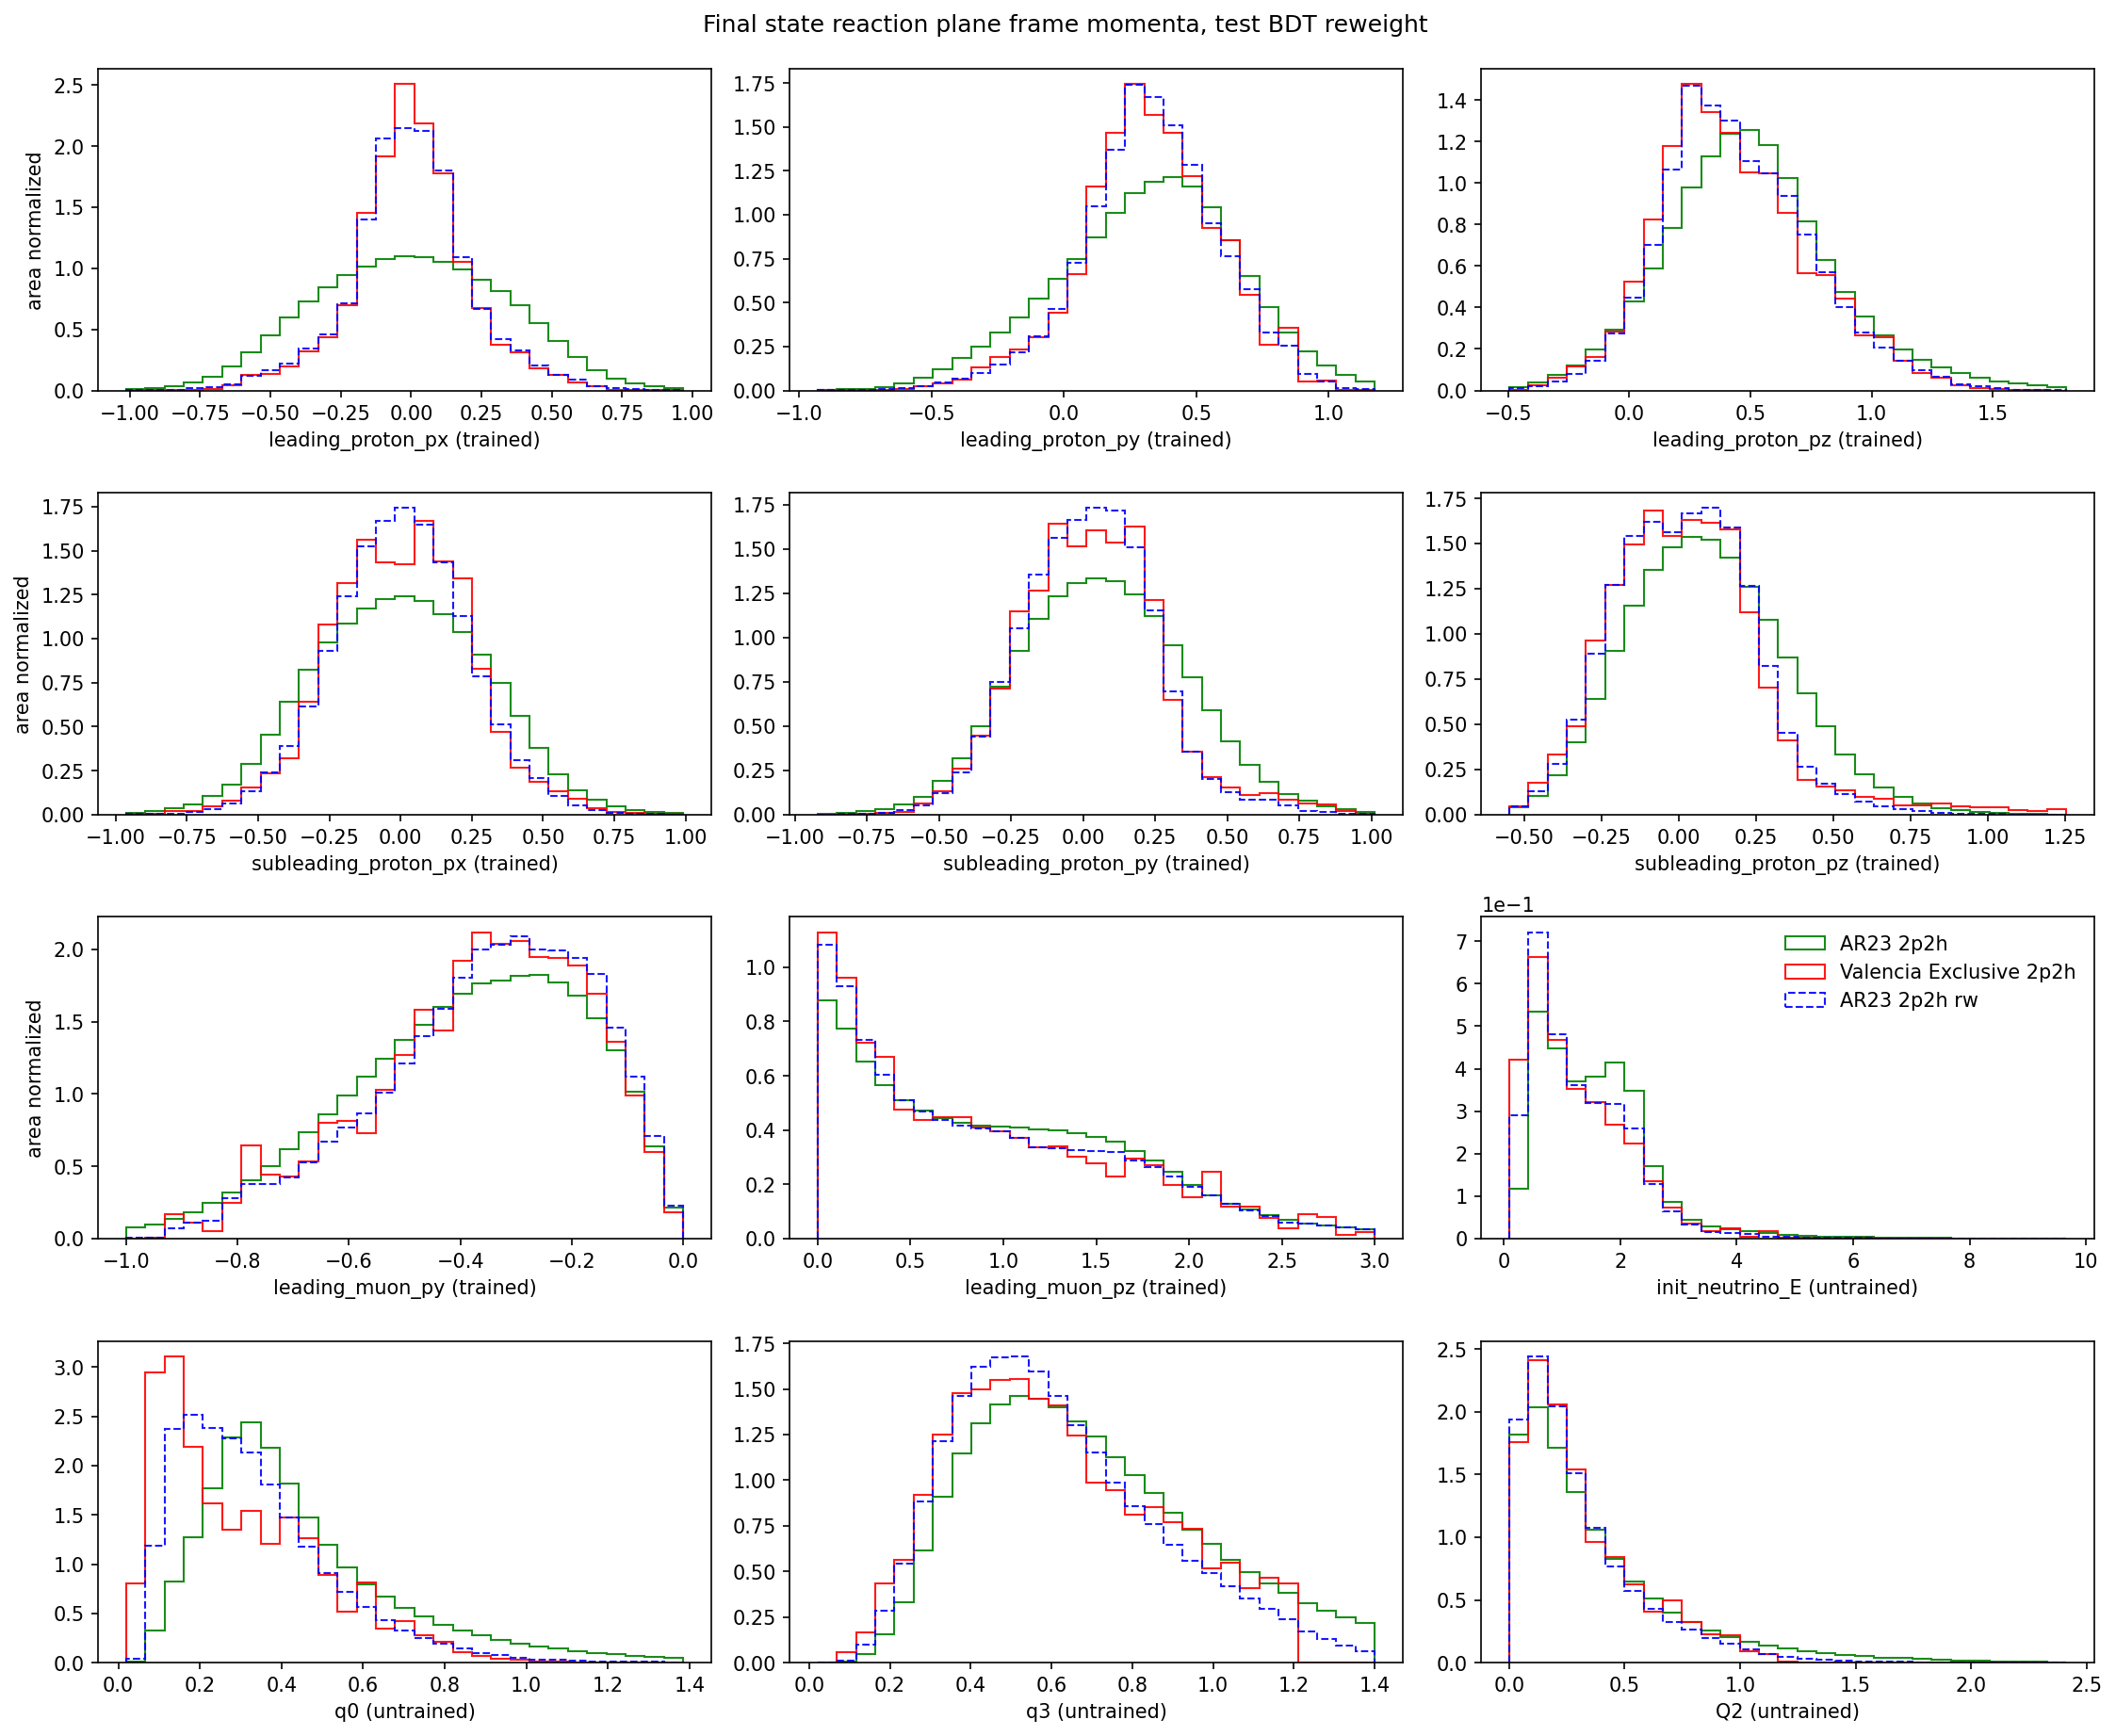

In [5]:
# plot reaction plane frame momenta
fig, axs = plt.subplots(nrows=4, ncols=3,figsize=(15,12), dpi=150)
for i, ax in enumerate(axs.flat):

    var = drawing_variables[i]
    if var == 'leading_muon_px':
        bins = np.linspace(-10, 10, 30)
    elif var == 'leading_muon_py':
        bins = np.linspace(-1, 0, 30)
    elif var == 'leading_muon_pz':
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), color='green', alpha=0.9,histtype='step',bins=bins, label='AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'],     color='red', alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h', density=True)
    ax.hist(df_source[var], weights=new_weights,             color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h rw', linestyle='--', density=True)
    ax.set_xlabel(var+' (trained)' if var in reweight_variables else var+' (untrained)')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
    if i == 8:
        ax.legend(frameon=False)
plt.tight_layout()
plt.suptitle('Final state reaction plane frame momenta, test BDT reweight', y = 1.02)
plt.show()

### pp reweight training with $E_\nu$:

In [6]:
# reweight variables (the ORDER matters) 
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz', 
    'init_neutrino_E'
]

# read reweighter from json
reweighter = load_json_reweighter('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_NuMI_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pp_bdtreweighter_trainWithEnu.json')
input_features = np.array(df_source[reweight_variables])

In [7]:
# use reweighter to predict weights for source sample
new_weights = reweighter.predict_weights(input_features)
print(new_weights)


[0.14082792 0.12908953 0.11859932 ... 0.10740246 0.1428706  0.11931213]


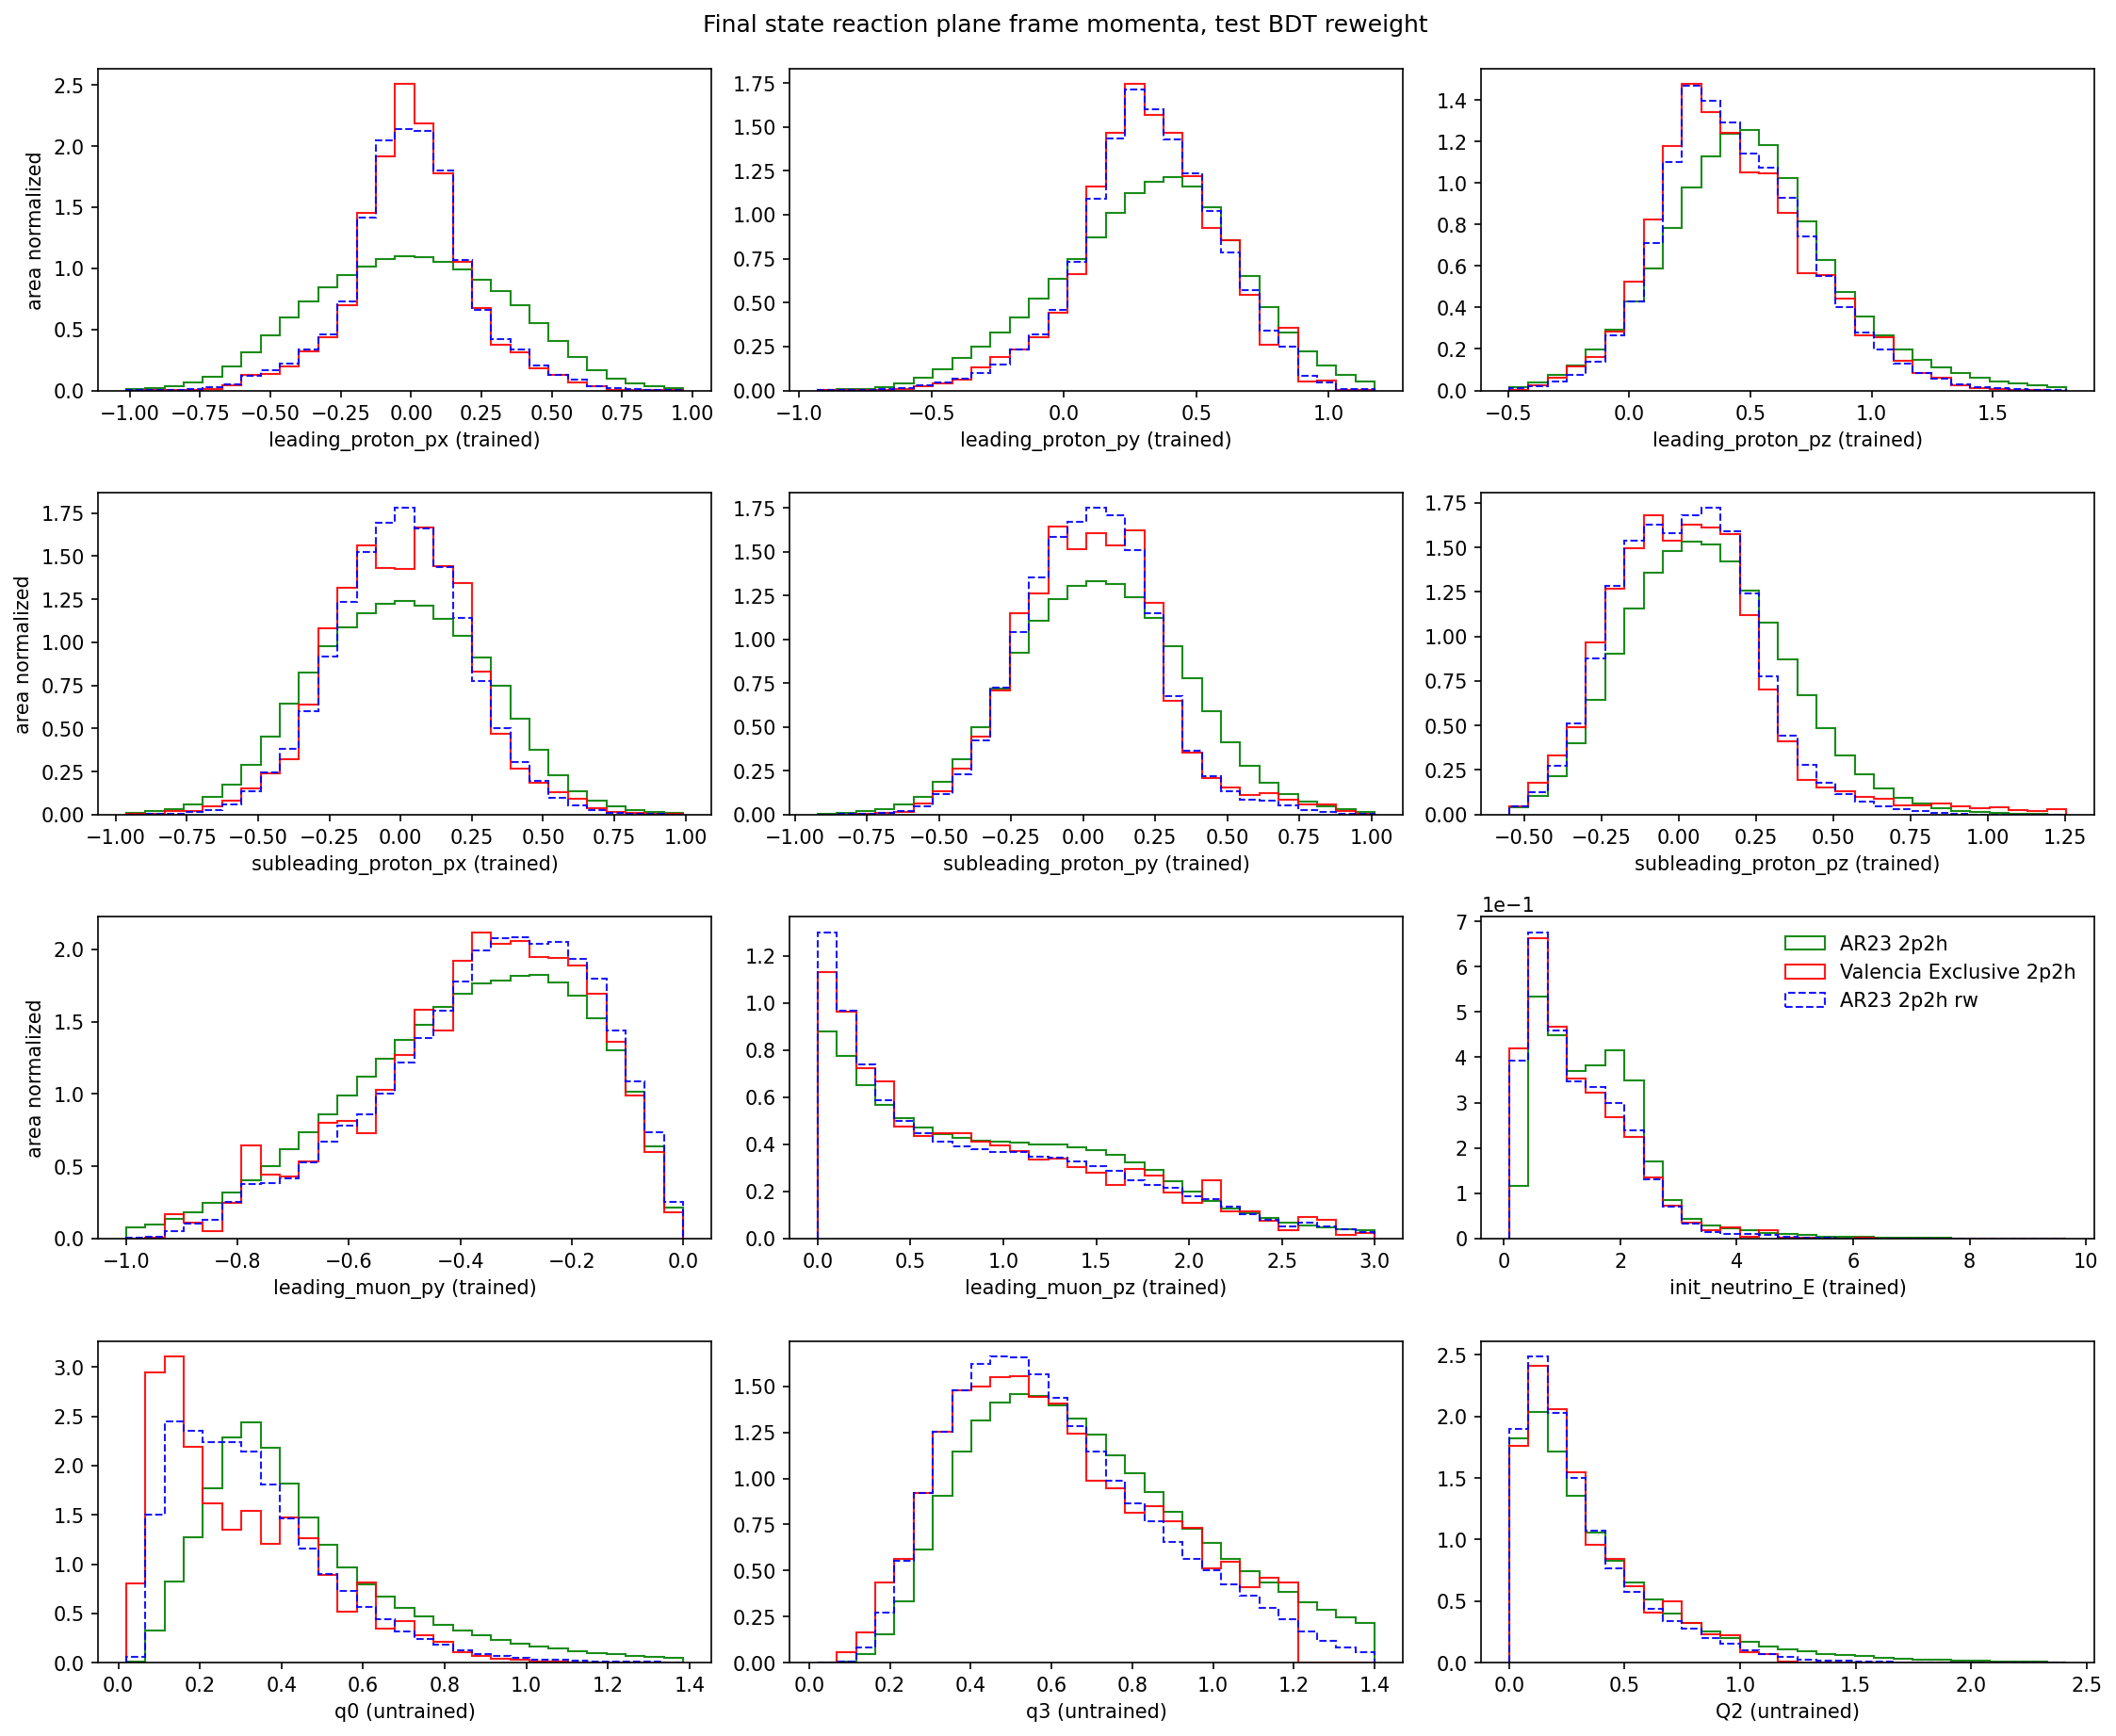

In [8]:
# plot reaction plane frame momenta
fig, axs = plt.subplots(nrows=4, ncols=3,figsize=(15,12), dpi=150)
for i, ax in enumerate(axs.flat):

    var = drawing_variables[i]
    if var == 'leading_muon_px':
        bins = np.linspace(-10, 10, 30)
    elif var == 'leading_muon_py':
        bins = np.linspace(-1, 0, 30)
    elif var == 'leading_muon_pz':
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), color='green', alpha=0.9,histtype='step',bins=bins, label='AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'],     color='red', alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h', density=True)
    ax.hist(df_source[var], weights=new_weights,             color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h rw', linestyle='--', density=True)
    ax.set_xlabel(var+' (trained)' if var in reweight_variables else var+' (untrained)')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
    if i == 8:
        ax.legend(frameon=False)
plt.tight_layout()
plt.suptitle('Final state reaction plane frame momenta, test BDT reweight', y = 1.02)
plt.show()

## Test BDT reweight pn out-going state events

In [9]:
# reweight variables (the ORDER matters) and drawing variables

drawing_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E', 'q0', 'q3', 'Q2'
]
# read muon, proton, neutron kinematics from pre-processed csv files
# these files already in reaction plane frame:
df_source = pd.read_csv('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/AR23SuSAv2_ICARUS_NuMI_2p2h_pn_states.csv') 
df_target = pd.read_csv('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/newValencia_ICARUS_NuMI_2p2h_pn_states.csv')
print("source csv columns:", df_source.columns)
print("target csv columns:", df_target.columns)

source csv columns: Index(['init_neutrino_E', 'q0', 'q3', 'Q2', 'leading_muon_px',
       'leading_muon_py', 'leading_muon_pz', 'leading_proton_px',
       'leading_proton_py', 'leading_proton_pz', 'leading_neutron_px',
       'leading_neutron_py', 'leading_neutron_pz', 'weight'],
      dtype='object')
target csv columns: Index(['leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
       'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
       'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
       'weight_pn', 'weight_np', 'init_neutrino_E', 'q0', 'q3', 'weight',
       'Q2'],
      dtype='object')


### pn reweight training without $E_\nu$:

In [10]:
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'leading_muon_py', 'leading_muon_pz',
    # 'init_neutrino_E'
]

reweighter = load_json_reweighter('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_NuMI_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pn_bdtreweighter.json')

input_features = np.array(df_source[reweight_variables])
new_weights = reweighter.predict_weights(input_features)
print(new_weights)

[0.04422291 0.46879777 0.88167966 ... 0.0076869  0.13080786 1.62694835]


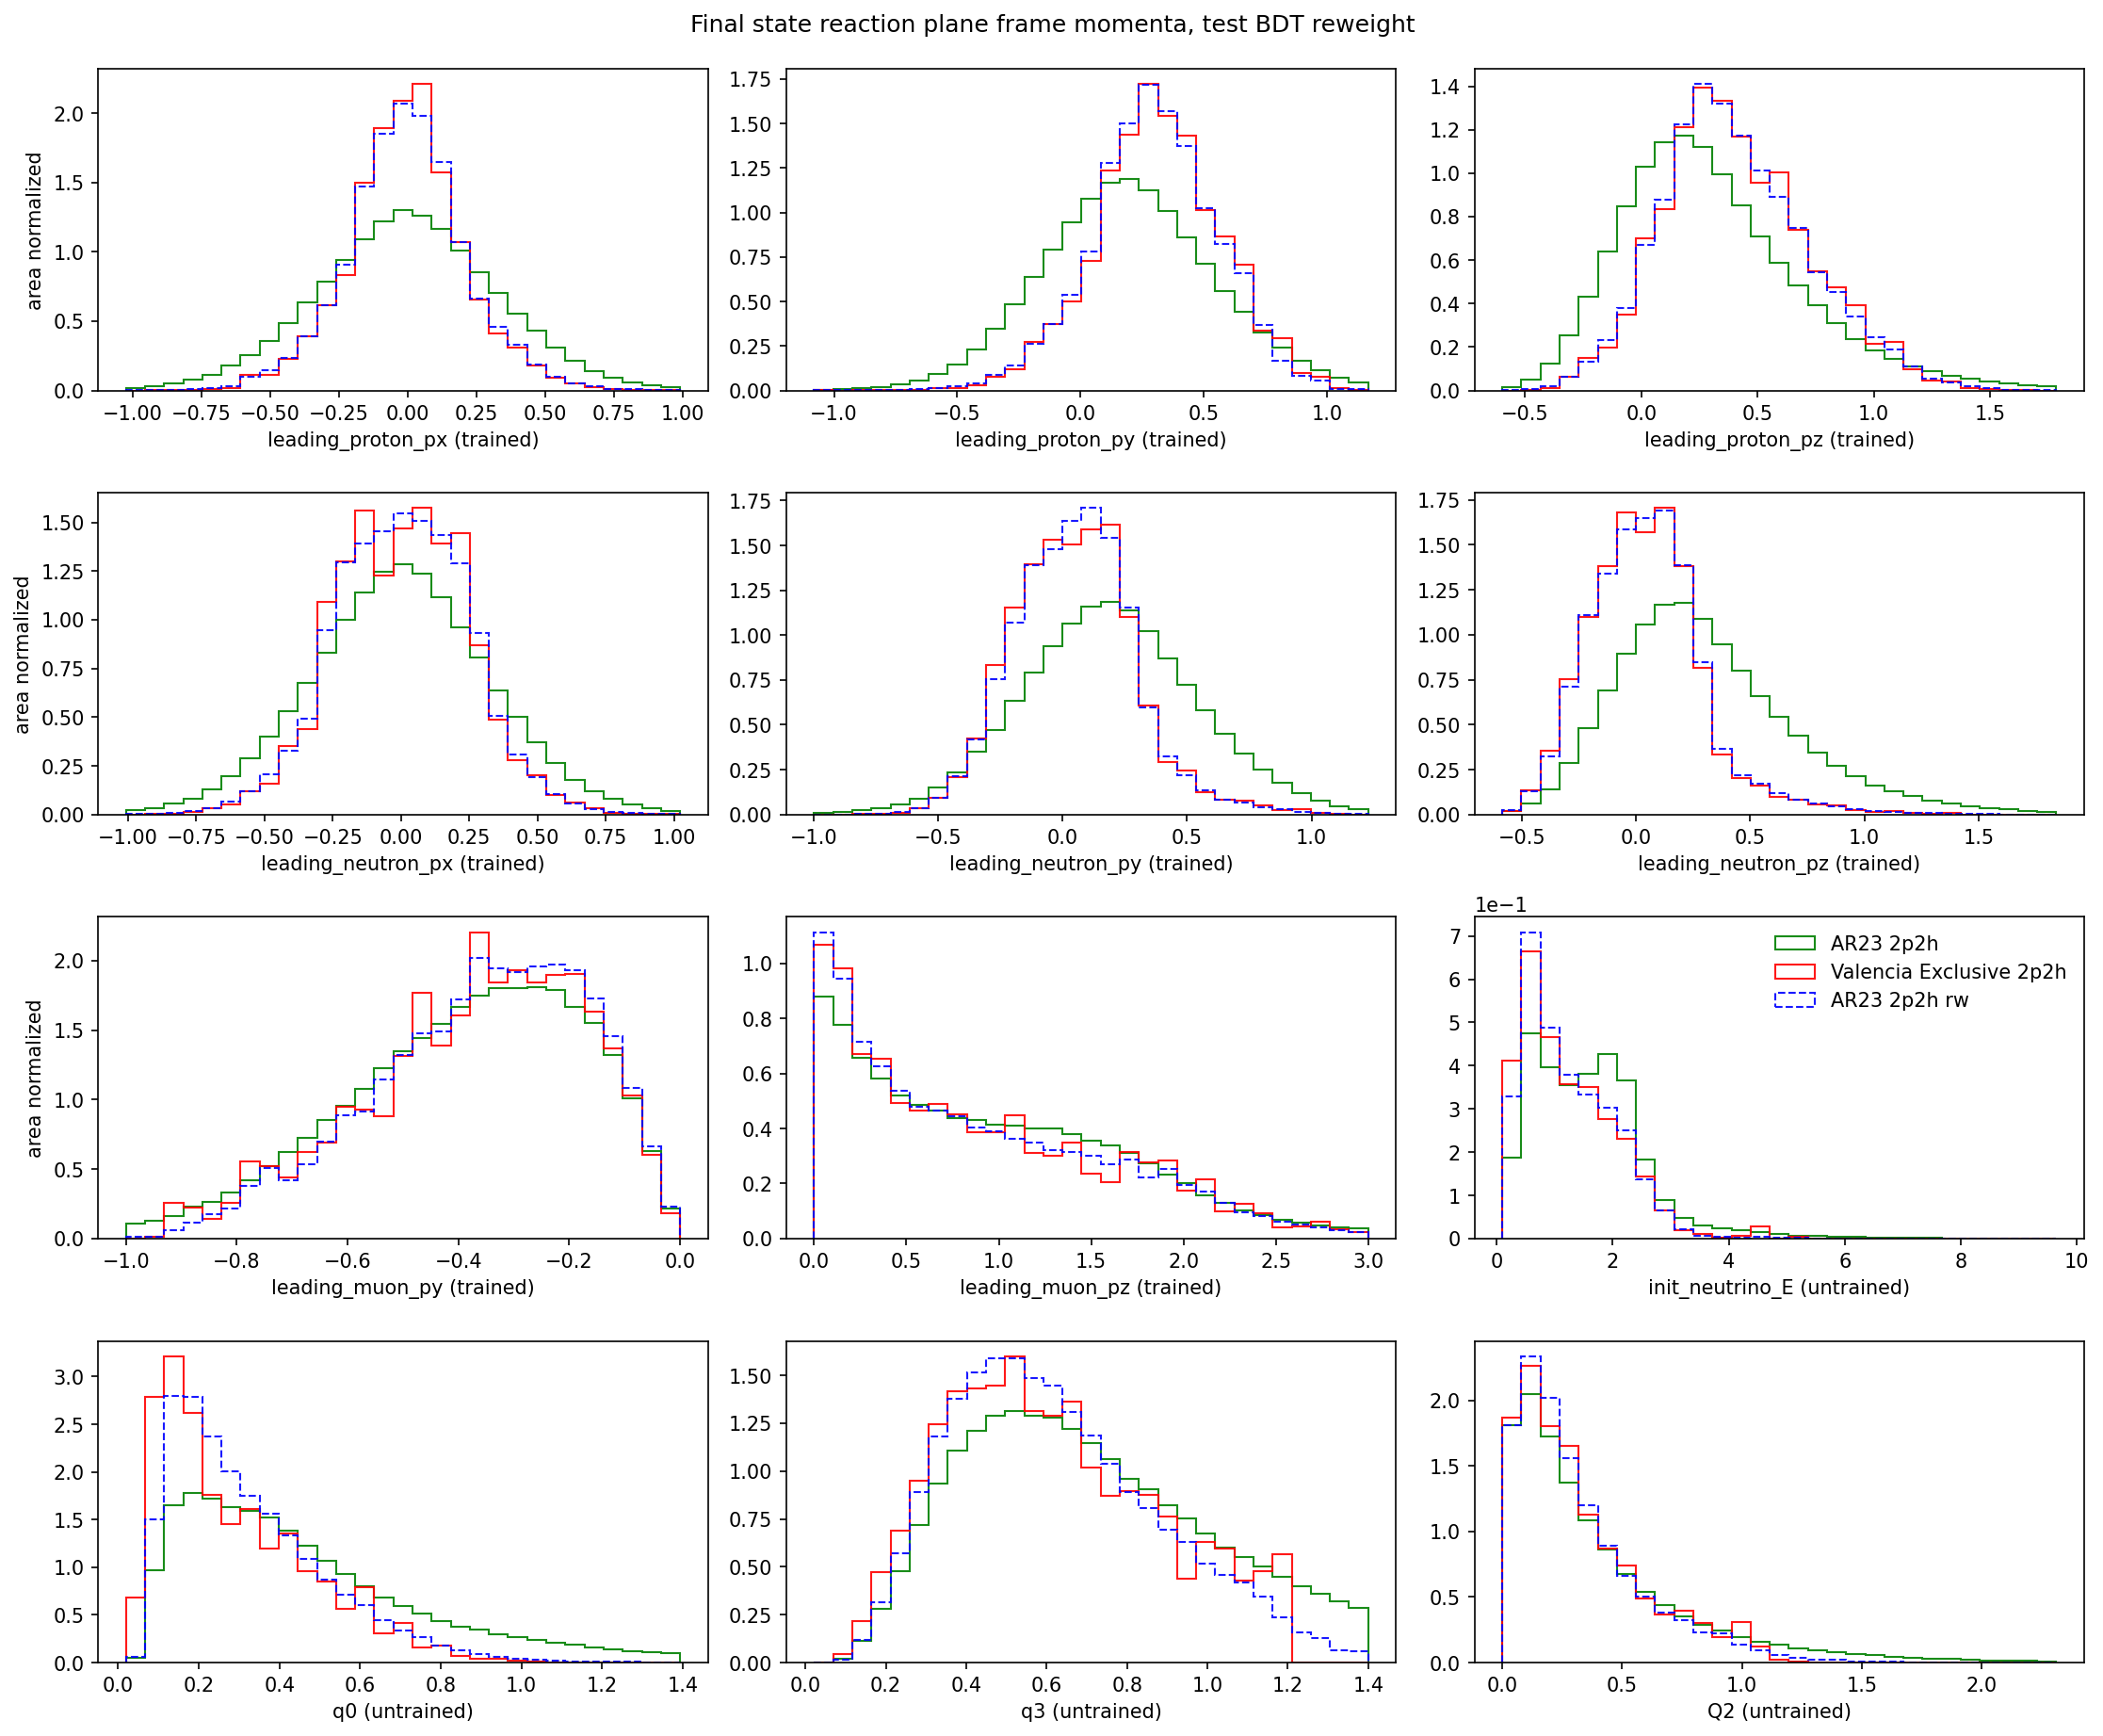

In [11]:
# plot reaction plane frame momenta
fig, axs = plt.subplots(nrows=4, ncols=3,figsize=(15,12), dpi=150)
for i, ax in enumerate(axs.flat):

    var = drawing_variables[i]
    if var == 'leading_muon_px':
        bins = np.linspace(-10, 10, 30)
    elif var == 'leading_muon_py':
        bins = np.linspace(-1, 0, 30)
    elif var == 'leading_muon_pz':
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), color='green', alpha=0.9,histtype='step',bins=bins, label='AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'],     color='red', alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h', density=True)
    ax.hist(df_source[var], weights=new_weights,             color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h rw', linestyle='--', density=True)
    ax.set_xlabel(var+' (trained)' if var in reweight_variables else var+' (untrained)')
    
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
    if i == 8:
        ax.legend(frameon=False)
plt.tight_layout()
plt.suptitle('Final state reaction plane frame momenta, test BDT reweight', y = 1.02)
plt.show()

### pn reweight training with $E_\nu$:

In [12]:
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E'
]

reweighter = load_json_reweighter('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_NuMI_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pn_bdtreweighter_trainWithEnu.json')

input_features = np.array(df_source[reweight_variables])
new_weights = reweighter.predict_weights(input_features)
print(new_weights)

[0.03489283 0.44540673 0.90405545 ... 0.00858416 0.20578486 1.51783605]


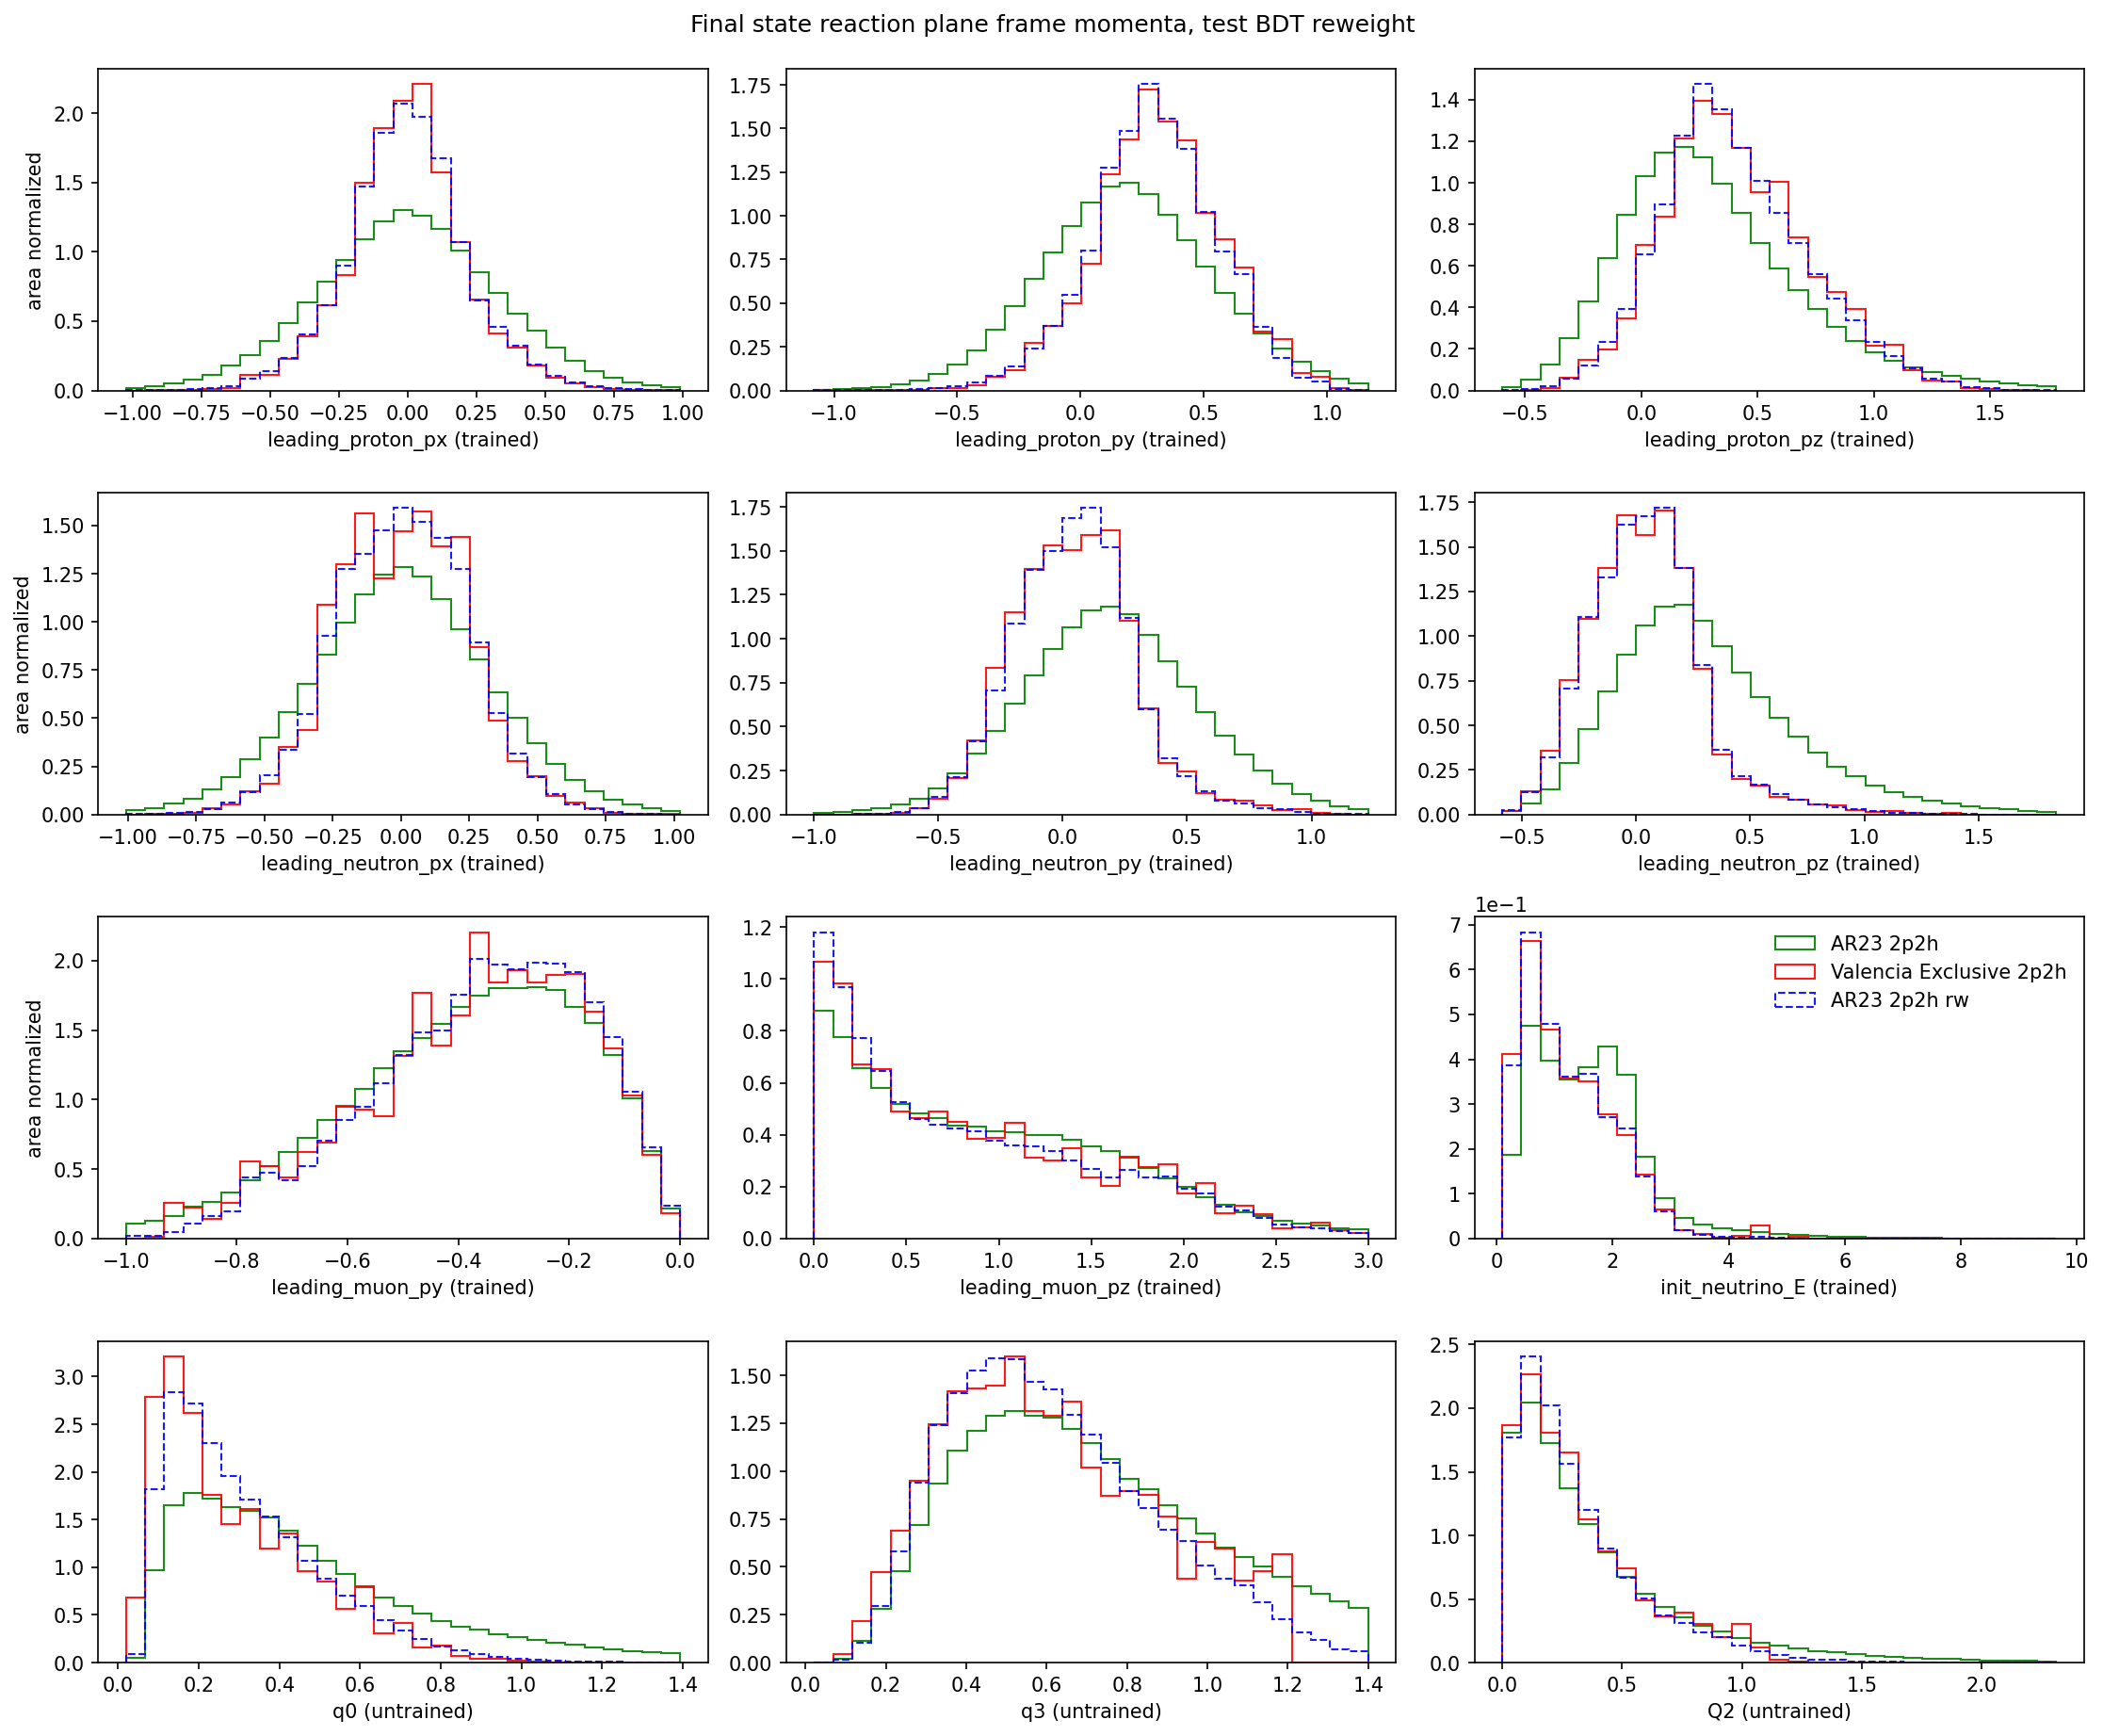

In [13]:
# plot reaction plane frame momenta
fig, axs = plt.subplots(nrows=4, ncols=3,figsize=(15,12), dpi=150)
for i, ax in enumerate(axs.flat):

    var = drawing_variables[i]
    if var == 'leading_muon_px':
        bins = np.linspace(-10, 10, 30)
    elif var == 'leading_muon_py':
        bins = np.linspace(-1, 0, 30)
    elif var == 'leading_muon_pz':
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), color='green', alpha=0.9,histtype='step',bins=bins, label='AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'],     color='red', alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h', density=True)
    ax.hist(df_source[var], weights=new_weights,             color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h rw', linestyle='--', density=True)
    ax.set_xlabel(var+' (trained)' if var in reweight_variables else var+' (untrained)')
    
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
    if i == 8:
        ax.legend(frameon=False)
plt.tight_layout()
plt.suptitle('Final state reaction plane frame momenta, test BDT reweight', y = 1.02)
plt.show()